## Time Analysis with Python


In [ ]:
import pandas as pd
import numpy as np
import gc

In [48]:
import pandas as pd
import numpy as np
import gc

txn = pd.read_csv("C:\\Users\\adity\\Documents\\Machine Learning\\fraud_detection_project\\data\\raw\\train_transaction.csv")
id = pd.read_csv("C:\\Users\\adity\\Documents\\Machine Learning\\fraud_detection_project\\data\\raw\\train_identity.csv")

df = pd.merge(txn, id, on="TransactionID", how="left")  # Merging the datasets 

## Calculating the hours when transaction happened. 

In [ ]:
df["hour_of_day"] = ((df["TransactionDT"] // 3600) % 24).astype(np.int8)  # Extracting hour of day from TransactionDT

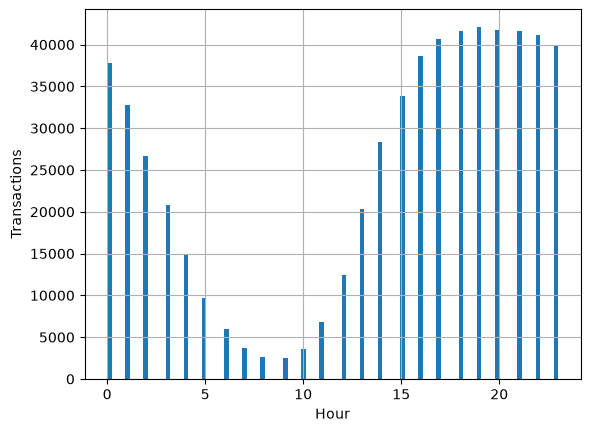

In [14]:
import matplotlib.pyplot as plt

df["hour_of_day"].hist(bins=100)
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

In [24]:
df.drop("hours", axis=1, inplace=True)

In [28]:
df.columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

# HOUR WHEN FRAUD OCCURRED:



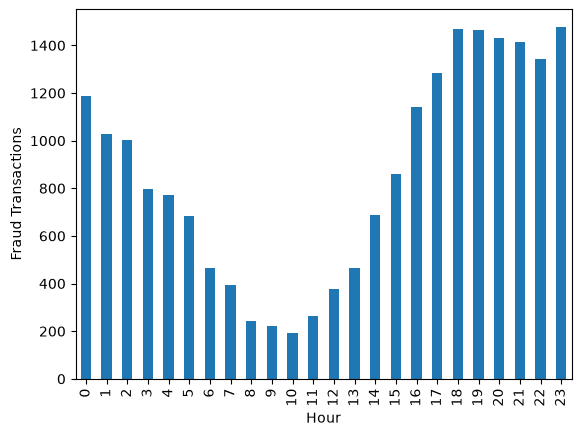

In [30]:
fraud = df[df["isFraud"] == 1]

fraud["hour_of_day"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Hour")
plt.ylabel("Fraud Transactions")
plt.show()

In [33]:
print(f'{fraud["hour_of_day"].value_counts().idxmax()}')


23


## Calculating the day  when transaction happened. 


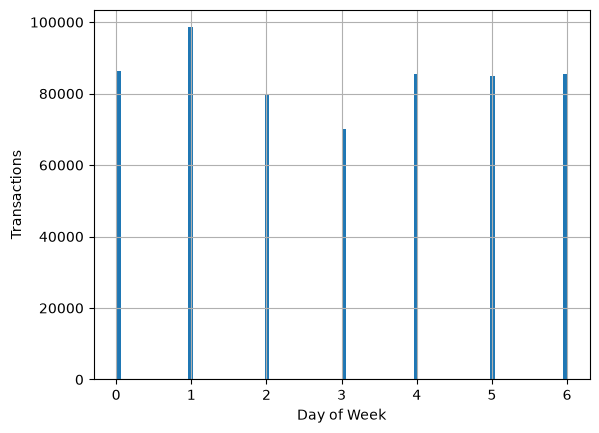

In [36]:
df["days_of_week"] = ((df["TransactionDT"] // (3600 * 24)) % 7).astype(np.int8)  # Extracting day of week from TransactionDT

df["days_of_week"].hist(bins=100)
plt.xlabel("Day of Week")
plt.ylabel("Transactions")
plt.show()

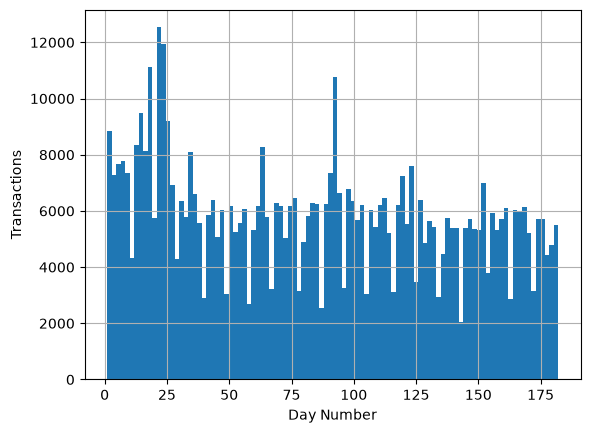

In [38]:
df["day_number"] = (df["TransactionDT"] // (3600 * 24)).astype(np.int16)  # Extracting day number from TransactionDT

df["day_number"].hist(bins=100)
plt.xlabel("Day Number")
plt.ylabel("Transactions")
plt.show()


In [44]:
print(df[["hour_of_day", "days_of_week", "day_number"]].tail(20))

        hour_of_day  days_of_week  day_number
590520           23             0         182
590521           23             0         182
590522           23             0         182
590523           23             0         182
590524           23             0         182
590525           23             0         182
590526           23             0         182
590527           23             0         182
590528           23             0         182
590529           23             0         182
590530           23             0         182
590531           23             0         182
590532           23             0         182
590533           23             0         182
590534           23             0         182
590535           23             0         182
590536           23             0         182
590537           23             0         182
590538           23             0         182
590539           23             0         182


## Finding the people which has identity

To do so, we need to figure out the device type and it should not be NA

In [47]:
df["has_identity"] = df["DeviceType"].notnull().astype(np.int8)  # Creating a new feature to indicate if identity information is present
print(df[["has_identity","DeviceType"]].head(20))

    has_identity DeviceType
0              0        NaN
1              0        NaN
2              0        NaN
3              0        NaN
4              1     mobile
5              0        NaN
6              0        NaN
7              0        NaN
8              1     mobile
9              0        NaN
10             1    desktop
11             1    desktop
12             0        NaN
13             0        NaN
14             0        NaN
15             0        NaN
16             1    desktop
17             1    desktop
18             0        NaN
19             0        NaN
